# Inspect emulators results

In [1]:
root = '/ceph/hpc/data/s25r06-05-users'

dataset_ranges = ['thin', 'std', 'ext']

## Init

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from tabulate import tabulate
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2025-10-29 15:39:18.855177: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 15:39:18.930110: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 15:39:18.941529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761748759.000036  538220 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761748759.005664  538220 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761748759.020313  538220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
class EmuData(object):

    def __init__(self, path_emu, root=root):
        self.name = path_emu
        self.emu = FFNNEmu()
        self.emu.load(os.path.join(root, path_emu), still_training=False)
        self.abs_diff = None
        self.rel_diff = None
        self.mean_abs_diff = None
        self.mean_rel_diff = None
        pass

    def _scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def _scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def _inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def _inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def _pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def _pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def _inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def _inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y_emu(self, x, want_scaling=False, want_pca=False, select_pca_modes=None, timeit=False):
        """
        From the emulator we get y that are potentially scaled and PCA
        applied. However, it is possible that just one or none of them
        are used. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        if timeit:
            start_all = time.time()

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        n_samples = x.shape[0]

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot keep scaled units: y is already unscaled.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        # 1) Adjust x
        # Adjust dimensions x array
        if x.ndim == 1:
            x = x[np.newaxis, :]
        # Scale x
        if self.emu.x_scaler is not None:
            x = self._scale_x(x)
        # PCA x
        if self.emu.x_pca is not None:
            x = self._pca_x(x)

        # 2) Emulate y
        if timeit:
            start_emu = time.time()
        result = self.emu.model(x, training=False).numpy()
        if timeit:
            stop_emu = time.time()

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if has_pca and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove scaling
        if has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        if timeit:
            stop_all = time.time()
        
        if timeit:
            self.time_emu = (stop_emu-start_emu)/n_samples
            self.time_all = (stop_all-start_all)/n_samples

        return result

    def get_y_data(self, y, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        Postprocess the data to add/remove scaling and PCA. It works to provide
        a compatible output of get_y_emu. Input data are assumed to not be scaled and
        without PCA applied. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot use scaled units: emulator has no scaling transform.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        result = y

        # 1) Scale
        if want_scaling or (want_pca_selection and has_scaling):
            result = self._scale_y(result)

        # 2) PCA
        if want_pca or want_pca_selection:
            result = self._pca_y(result)

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if want_pca_selection and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove Scale
        if want_pca_selection and has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_abs_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the absolute difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.abs_diff = y_emu - y_data
        return self.abs_diff
    
    def get_rel_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the relative difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.rel_diff = y_emu/y_data -1.
        return self.rel_diff

    def get_mean_abs_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.abs_diff = self.get_abs_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_abs_diff = np.sqrt(np.mean(self.abs_diff**2., axis=1))
        return self.mean_abs_diff
    
    def get_mean_rel_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.rel_diff = self.get_rel_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_rel_diff = np.sqrt(np.mean(self.rel_diff**2., axis=1))
        return self.mean_rel_diff

    def get_sorting_idxs_abs(self):
        if self.mean_abs_diff is None:
            raise Exception('Calculate mean_abs_diff first')
        return self.mean_abs_diff.argsort()[::-1]

    def get_sorting_idxs_rel(self):
        if self.mean_rel_diff is None:
            raise Exception('Calculate mean_rel_diff first')
        return self.mean_rel_diff.argsort()[::-1]

In [4]:
def load_emus(paths_emu, dataset_ranges, root):
    emudata = {}
    for path in paths_emu:
        emudata[path] = {}
        for dr in dataset_ranges:
            emudata[path][dr] = EmuData(path, root=root)
    return emudata

In [5]:
def load_data(spectrum, spectrum_type, dataset_ranges, root):
    x_data = {}
    y_data = {}
    for dr in dataset_ranges:
        path_dataset = os.path.join(root, 'lcdm/sample/{}_100_{}.fits'.format(spectrum_type, dr))
        dataset = io.FitsFile(path_dataset)
        x_data[dr] = dataset.get_data('x_data')
        y_data[dr] = dataset.get_data(spectrum)
    return x_data, y_data
    

In [6]:
def show_summary(emudata, x_data, y_data, paths_emu, dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.]):
    # Create figure
    fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False, sharex=True)
    fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

    # Init table
    headers = ['name'] + ['>{}%'.format(val) for val in vlines] + ['Time emu (s)', 'Time get_y_emu (s)']
    tab = []

    # Plot data in each subplot
    for npath, path in enumerate(paths_emu):
        name = os.path.split(path)[-1]
        for ndr, dr in enumerate(dataset_ranges):

            mrd = emudata[path][dr].get_mean_rel_diff(
                x_emu=x_data[dr],
                y_data=y_data[dr],
                want_scaling=False,
                want_pca=False,
                select_pca_modes_emu=None,
                select_pca_modes_data=None,
                time_emu=True)
            
            # Table
            if ndr == 0:
                tab.append(['{}'.format(name)] + (len(vlines)+2)*[''])
            tab_line = ['---> {}'.format(dr)]
            tab_line += ['{:.3f}%'.format(len(mrd[mrd>val/100.])/len(mrd)*100.)
                        for val in vlines]
            tab_line += ['{:.1e}'.format(emudata[path][dr].time_emu)]
            tab_line += ['{:.1e}'.format(emudata[path][dr].time_all)]        
            tab.append(tab_line)

            # Figure
            axs[npath, ndr].hist(np.log10(mrd), log=True, bins=20)
            axs[npath, ndr].set_title('{} - {}'.format(name, dr), fontsize=18)
            axs[npath, ndr].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)
            for val in vlines:
                axs[npath, ndr].axvline(x=np.log10(val/100.), c='r')

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print table
    print(tabulate(tab, headers=headers, tablefmt='orgtbl'))

    return

In [7]:
def plot_worst_modes(emudata, paths_emu, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.]):
    fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False, sharey=True)
    fig.suptitle('Worst modes', fontsize=30, y=1.0)

    for npath, path in enumerate(paths_emu):
        name = os.path.split(path)[-1]
        for ndr, dr in enumerate(dataset_ranges):
            idxs = emudata[path][dr].get_sorting_idxs_rel()[:n_modes_kept]
            diffs = emudata[path][dr].rel_diff[idxs]

            for val in vlines:
                axs[npath, ndr].axhline(val, c='k', lw=0.1)

            for ndiff, diff in enumerate(diffs):
                axs[npath, ndr].plot(np.abs(diff)*100., label='rank: {}, idx: {}'.format(ndiff+1, idxs[ndiff]))
                axs[npath, ndr].set_yscale('log')
                axs[npath, ndr].set_title('{} - {}'.format(name, dr), fontsize=18)
            axs[npath, 0].set_ylabel('rel diff [%]')

            axs[npath, ndr].legend()
    return


## Cls TT (without LogStandardScaler)

In [8]:
spectrum_type = 'cl'
spectrum = 'cl_TT_lensed'
paths_emu = [
    'lcdm/train/test_cl_512_x2',
    'lcdm/train/test_cl_512_x2_std',
    'lcdm/train/test_cl_1024_x2',
    'lcdm/train/test_cl_1024_x4',
    'lcdm/train/test_cl_512_x2_logstd',
]

In [9]:
# Load emulators
emudata = load_emus(paths_emu, dataset_ranges, root)
# Load data
x_data, y_data = load_data(spectrum, spectrum_type, dataset_ranges, root)

2025-10-29 15:40:32.532111: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2025-10-29 15:42:39.766603: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-10-29 15:42:39.784898: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-10-29 15:42:39.816915: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-10-29 15:42:39.847883: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-10-29 15:42:39.908932: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.


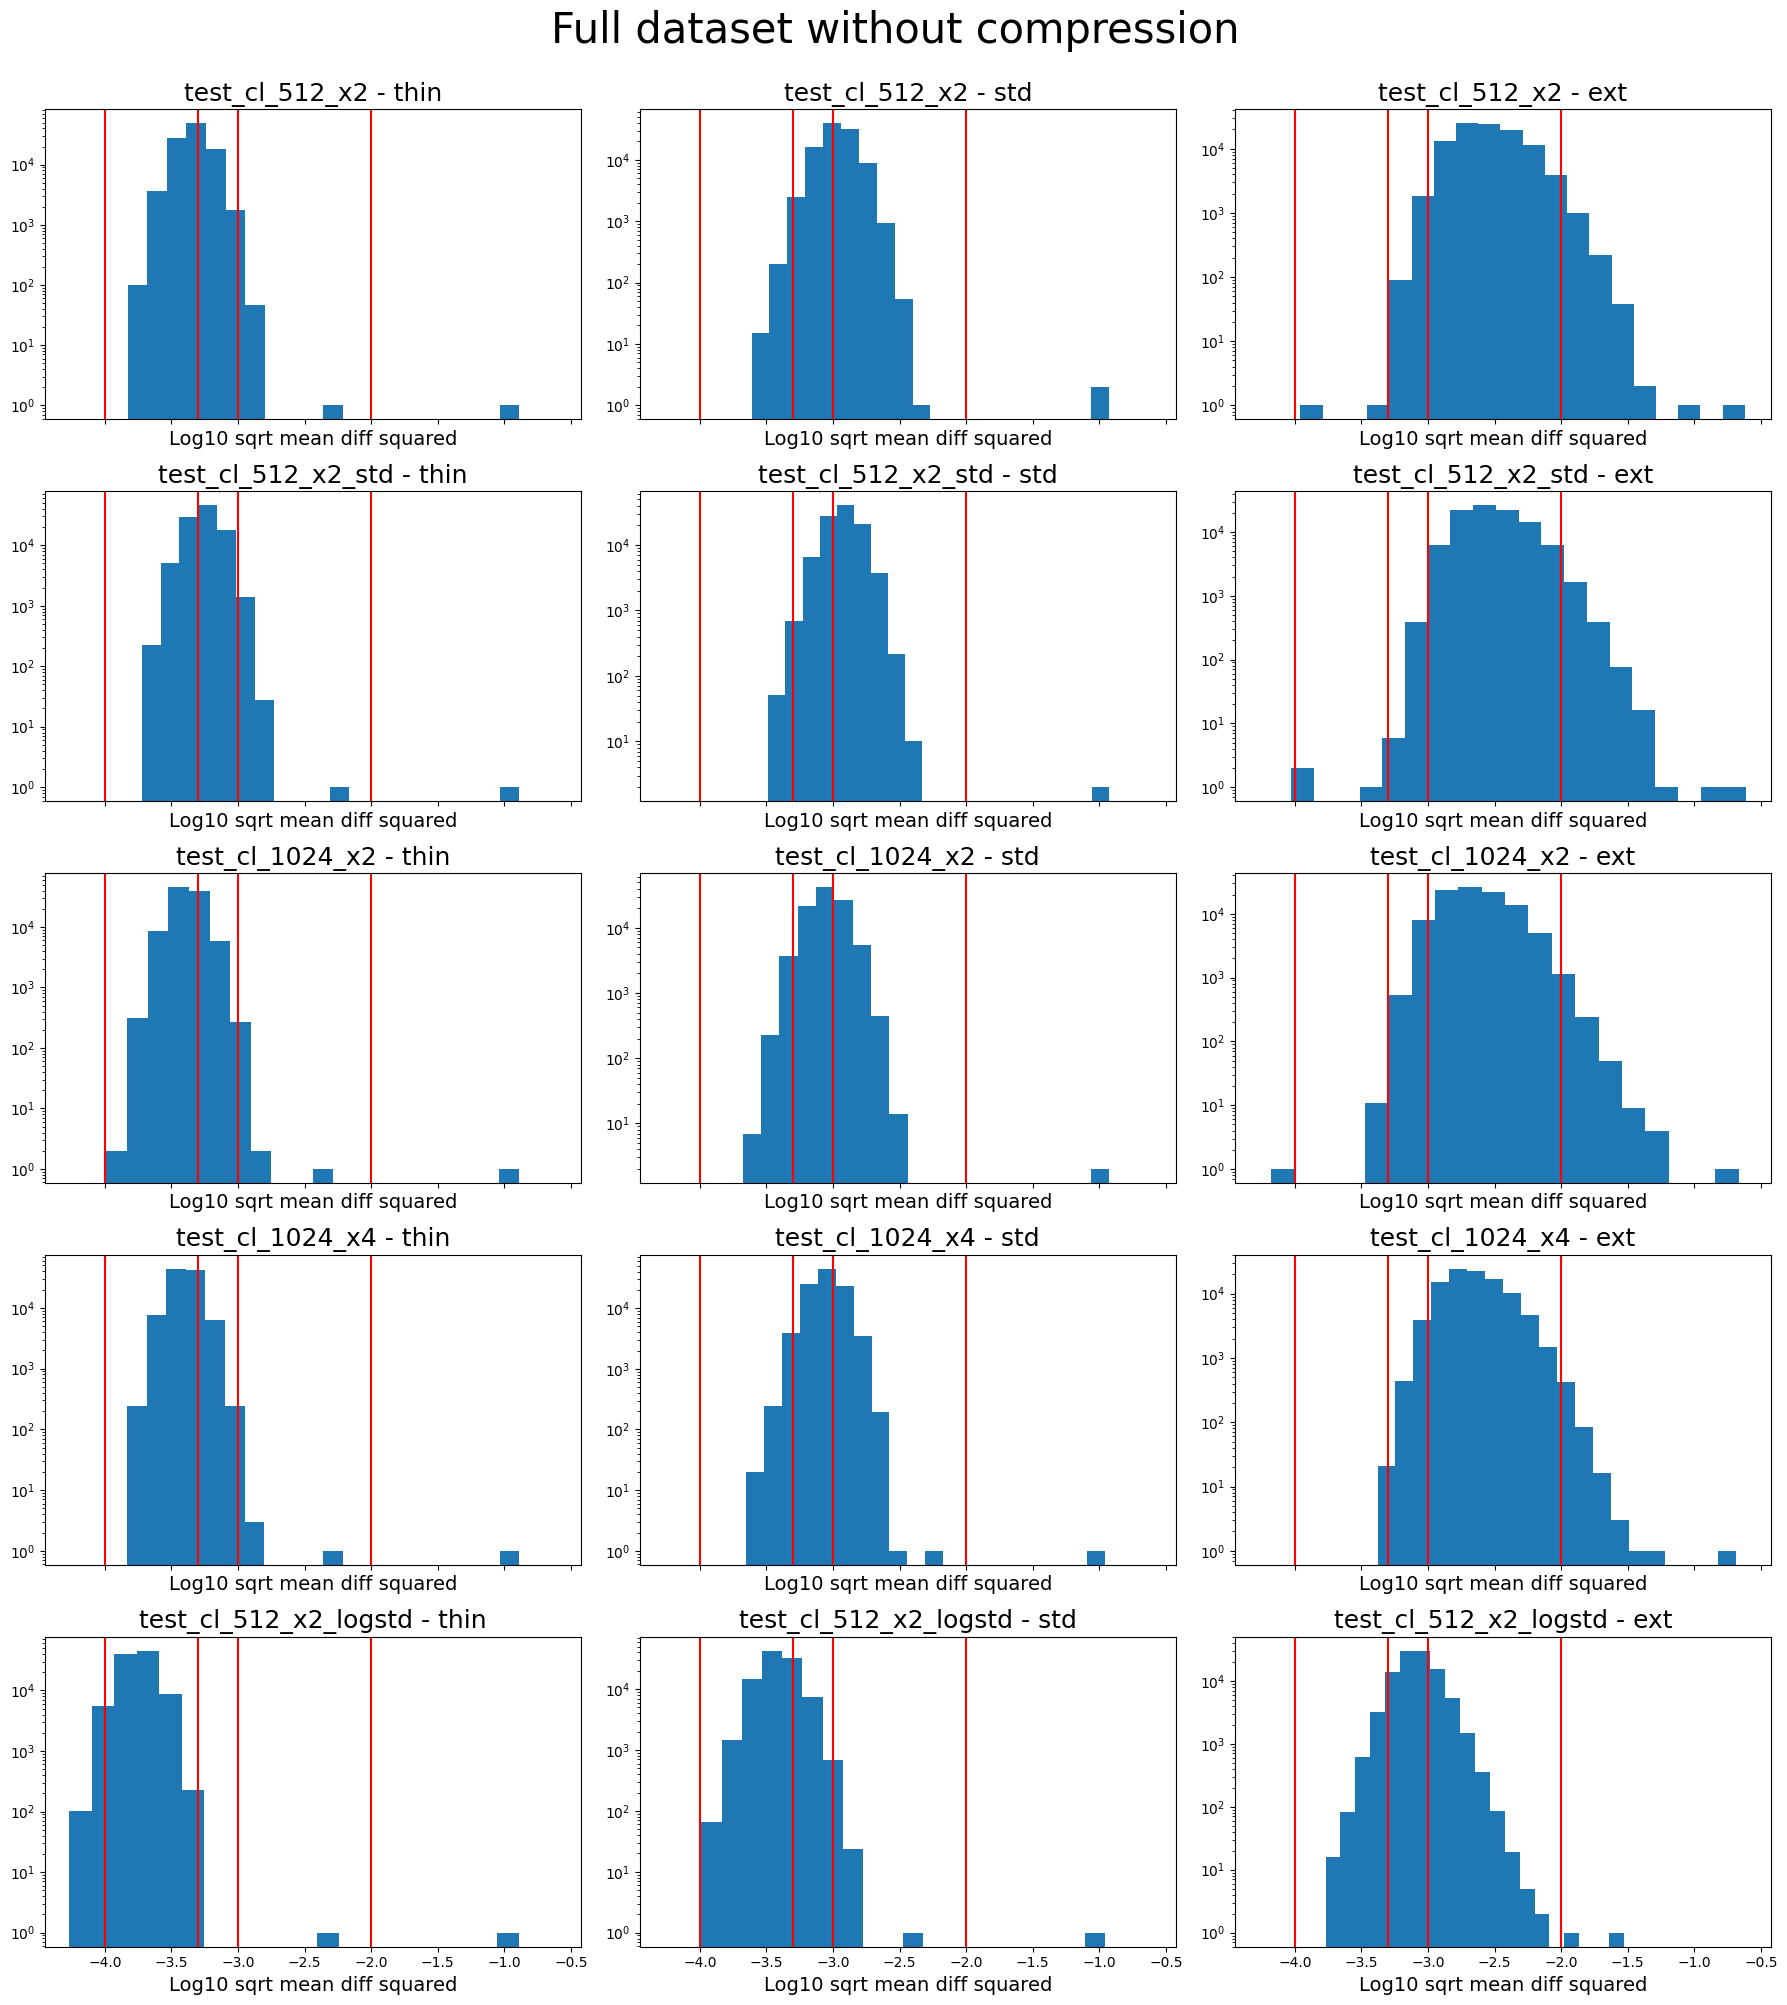

| name                  | >0.01%   | >0.05%   | >0.1%   | >1.0%   | Time emu (s)   | Time get_y_emu (s)   |
|-----------------------+----------+----------+---------+---------+----------------+----------------------|
| test_cl_512_x2        |          |          |         |         |                |                      |
| ---> thin             | 100.000% | 38.094%  | 0.217%  | 0.001%  | 4.4e-06        | 4.3e-05              |
| ---> std              | 100.000% | 99.542%  | 60.671% | 0.002%  | 2.1e-06        | 7.3e-05              |
| ---> ext              | 100.000% | 99.998%  | 99.077% | 1.864%  | 1.9e-06        | 3.9e-05              |
| test_cl_512_x2_std    |          |          |         |         |                |                      |
| ---> thin             | 100.000% | 66.200%  | 0.992%  | 0.001%  | 1.9e-06        | 2.2e-05              |
| ---> std              | 100.000% | 99.836%  | 73.048% | 0.002%  | 1.8e-06        | 2.1e-05              |
| ---> ext              | 99

In [10]:
show_summary(emudata, x_data, y_data, paths_emu, dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.])

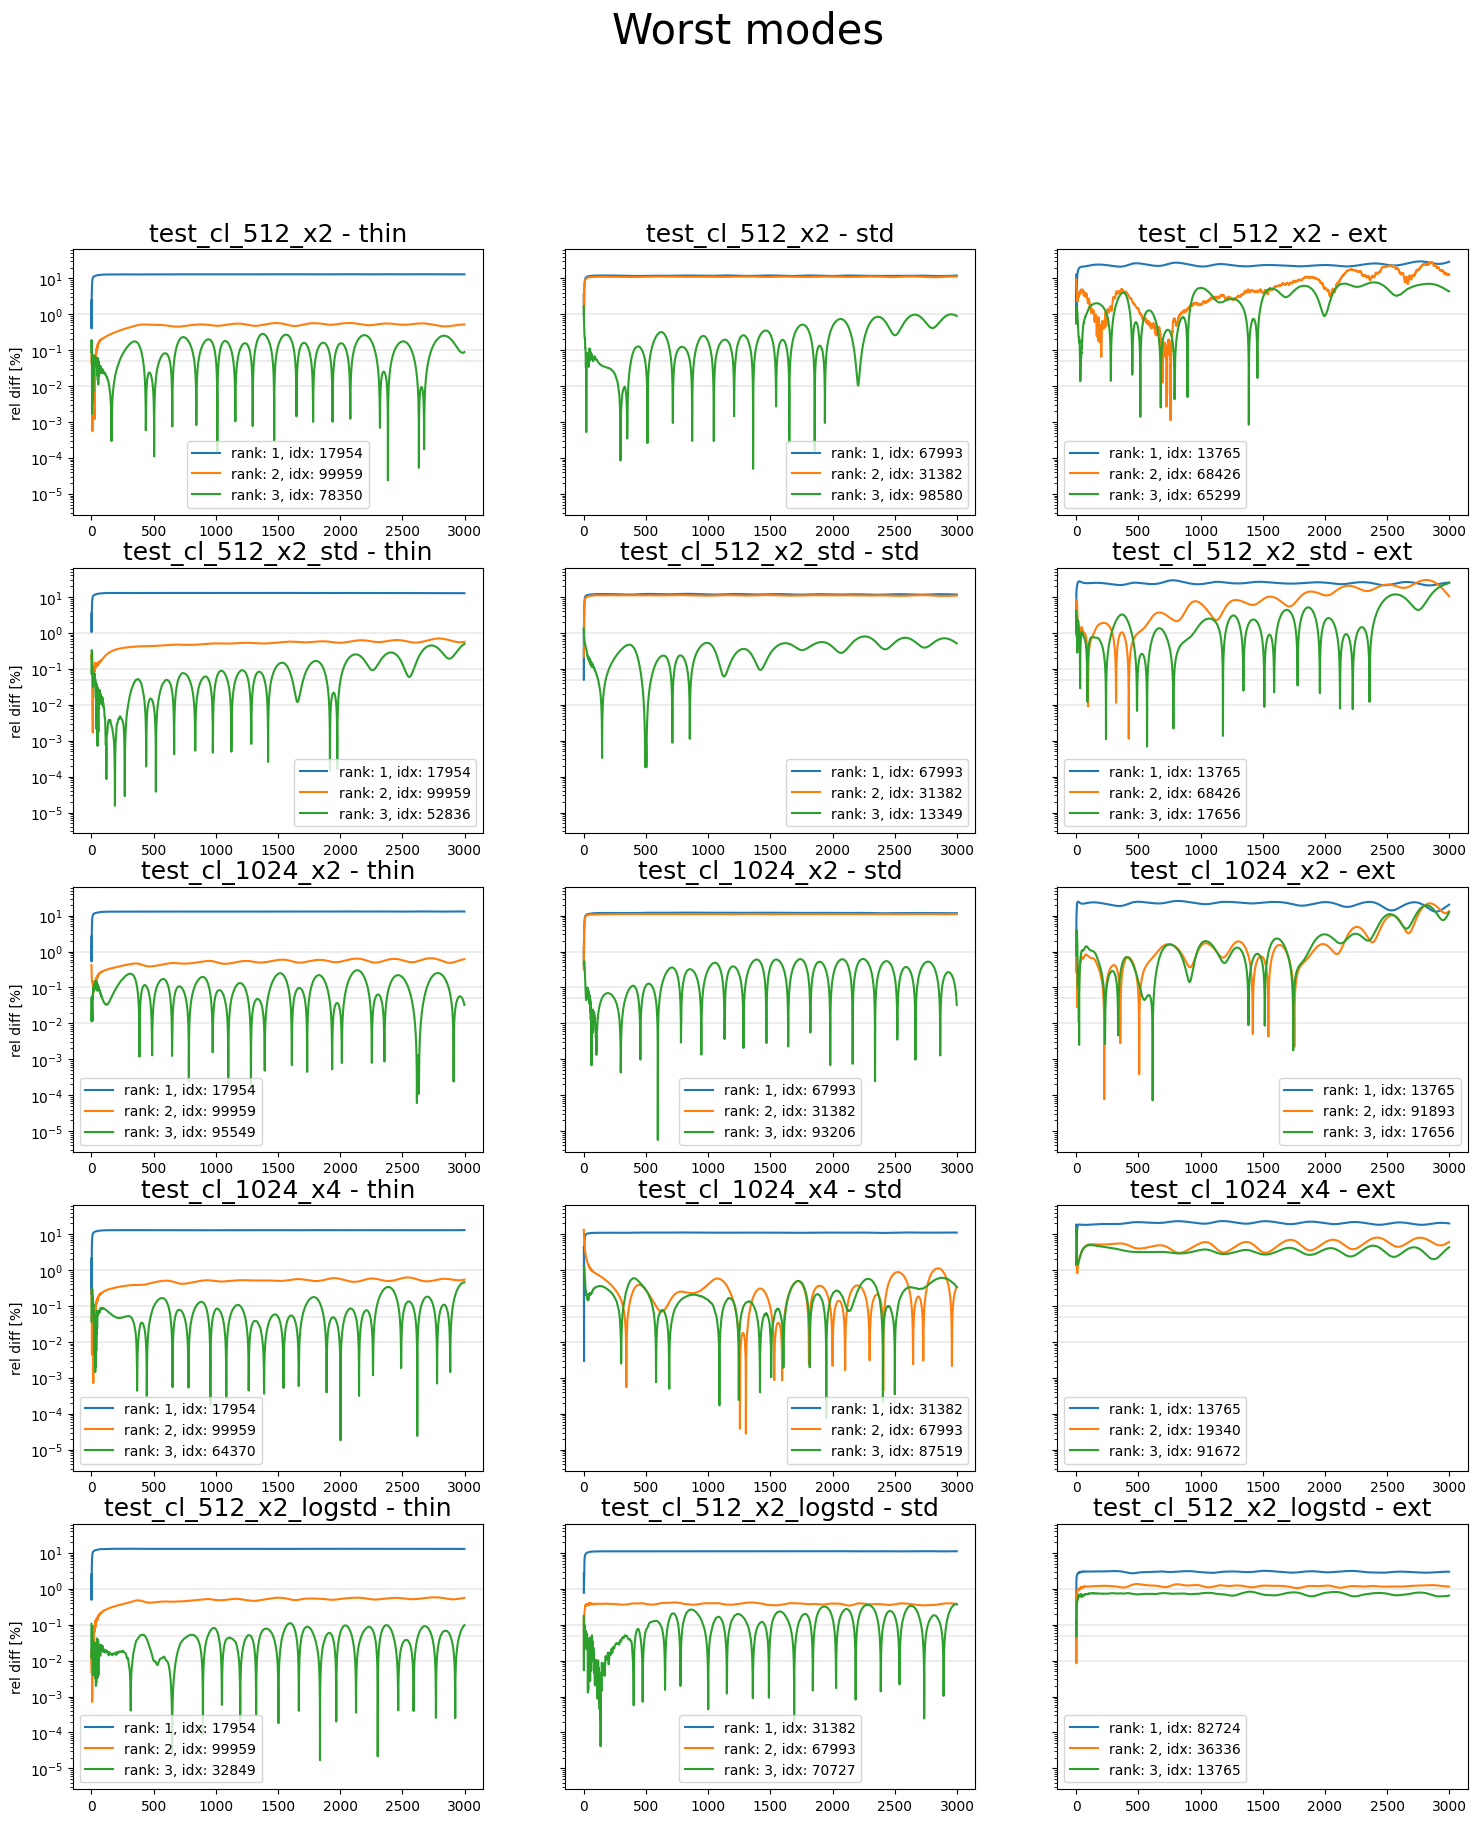

In [11]:
plot_worst_modes(emudata, paths_emu, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.])

## Cls TT

In [12]:
spectrum_type = 'cl'
spectrum = 'cl_TT_lensed'
paths_emu = [
    'lcdm/train/test_cl_512_x2_logstd',
    # 'lcdm/train/test_cl_512_x4_logstd',
    # 'lcdm/train/test_cl_1024_x2_logstd',
    'lcdm/train/test_cl_1024_x4_logstd',
]

In [13]:
# Load emulators
emudata = load_emus(paths_emu, dataset_ranges, root)
# Load data
x_data, y_data = load_data(spectrum, spectrum_type, dataset_ranges, root)

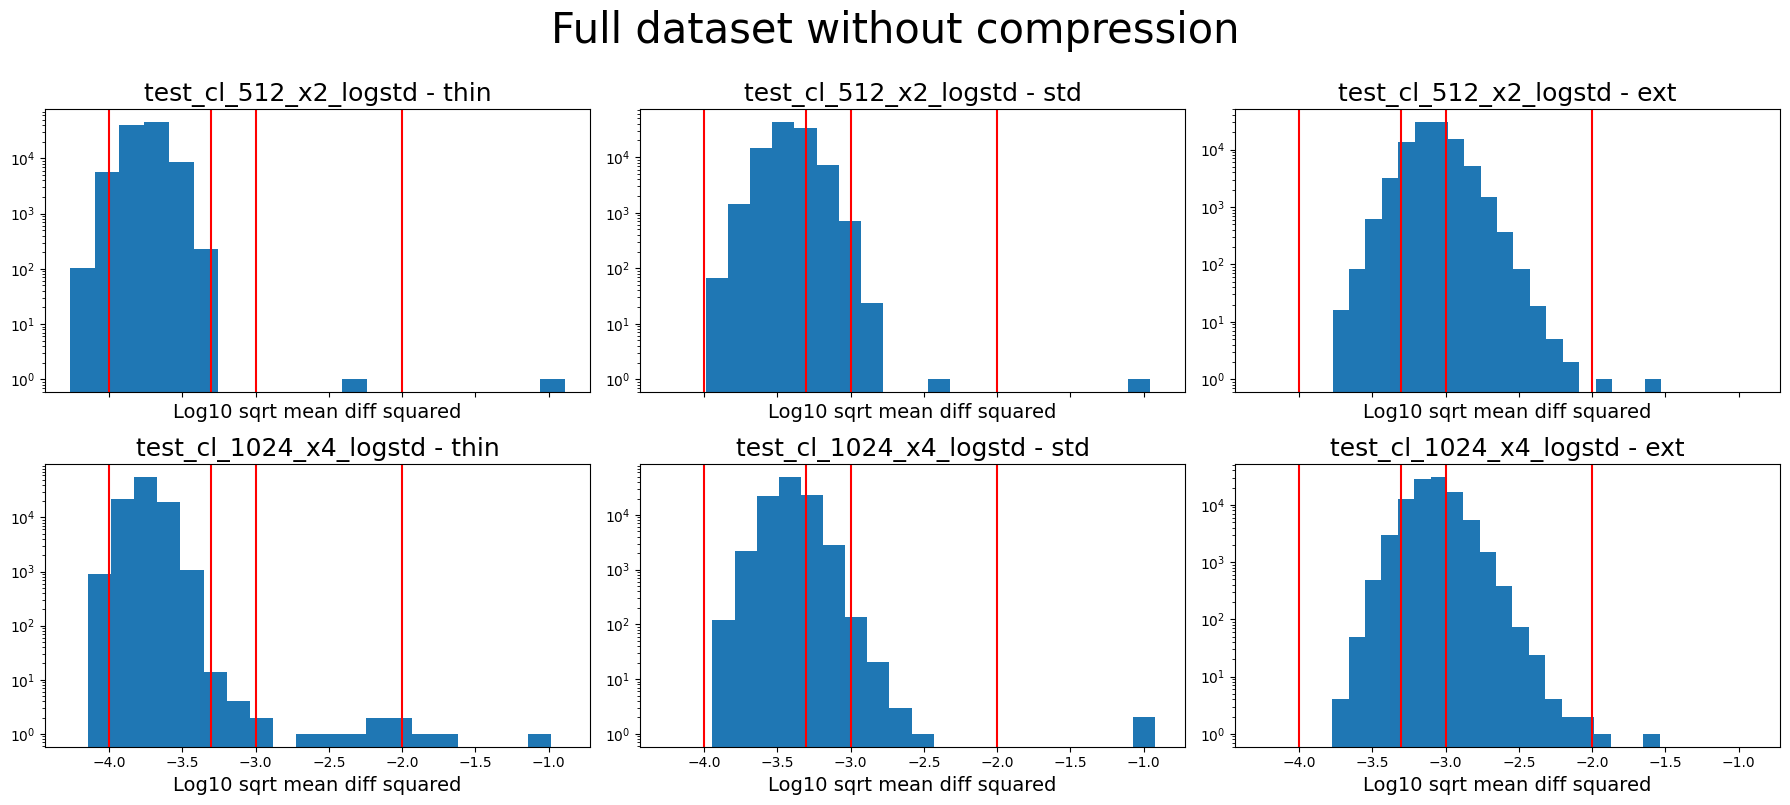

| name                   | >0.01%   | >0.05%   | >0.1%   | >1.0%   | Time emu (s)   | Time get_y_emu (s)   |
|------------------------+----------+----------+---------+---------+----------------+----------------------|
| test_cl_512_x2_logstd  |          |          |         |         |                |                      |
| ---> thin              | 98.665%  | 0.002%   | 0.002%  | 0.001%  | 1.9e-06        | 5.1e-05              |
| ---> std               | 100.000% | 19.292%  | 0.152%  | 0.001%  | 2.1e-06        | 5.2e-05              |
| ---> ext               | 100.000% | 94.707%  | 25.755% | 0.002%  | 1.8e-06        | 5.3e-05              |
| test_cl_1024_x4_logstd |          |          |         |         |                |                      |
| ---> thin              | 99.400%  | 0.024%   | 0.012%  | 0.004%  | 5.7e-06        | 5.5e-05              |
| ---> std               | 100.000% | 16.681%  | 0.085%  | 0.002%  | 5.5e-06        | 5.5e-05              |
| ---> ext         

In [14]:
show_summary(emudata, x_data, y_data, paths_emu, dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.])

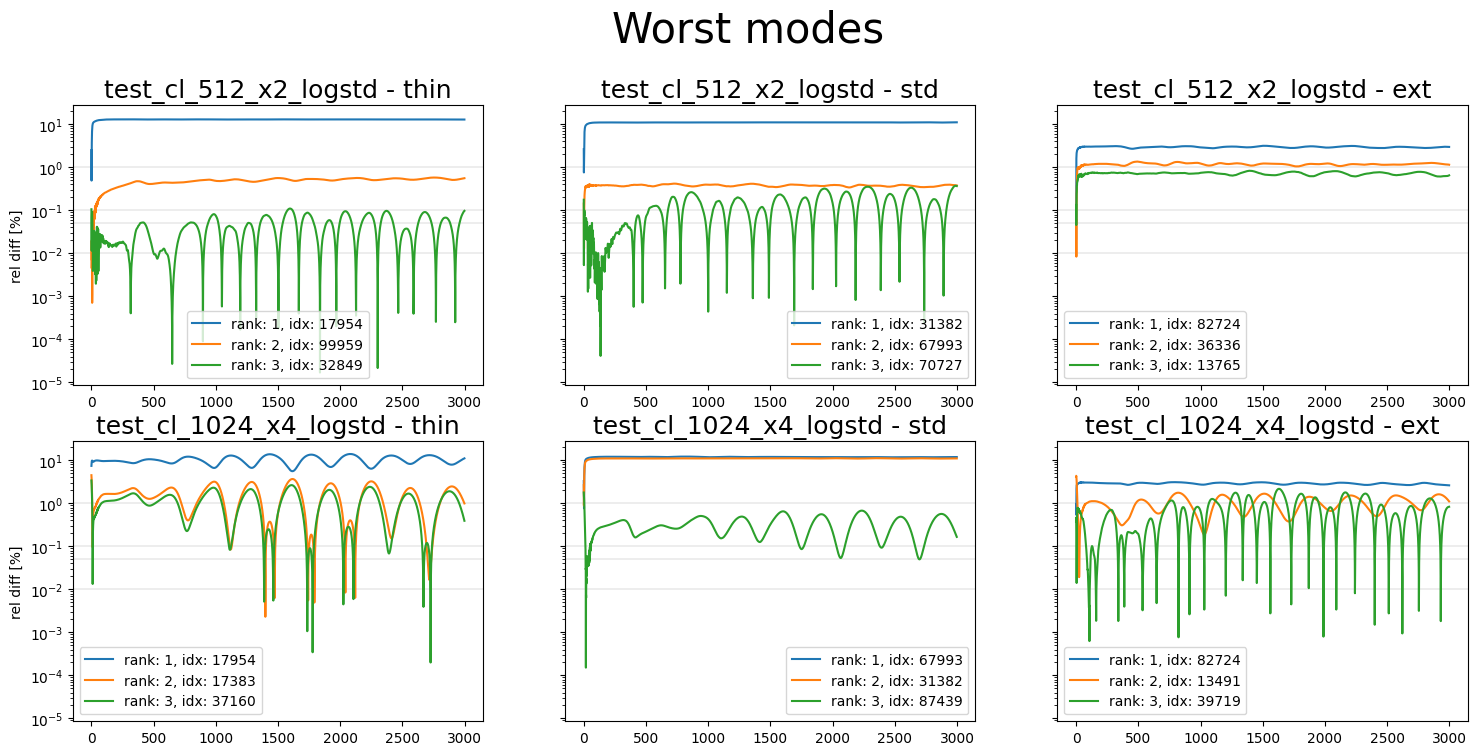

In [15]:
plot_worst_modes(emudata, paths_emu, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.])

## Pk matter (without LogStandardScaler)

In [16]:
spectrum_type = 'pk'
spectrum = 'pk_m'
paths_emu = [
    'lcdm/train/test_pk_512_x2',
    'lcdm/train/test_pk_1024_x2',
    'lcdm/train/test_pk_1024_x4',
    'lcdm/train/test_pk_512_x2_logstd',
]

In [17]:
# Load emulators
emudata = load_emus(paths_emu, dataset_ranges, root)
# Load data
x_data, y_data = load_data(spectrum, spectrum_type, dataset_ranges, root)

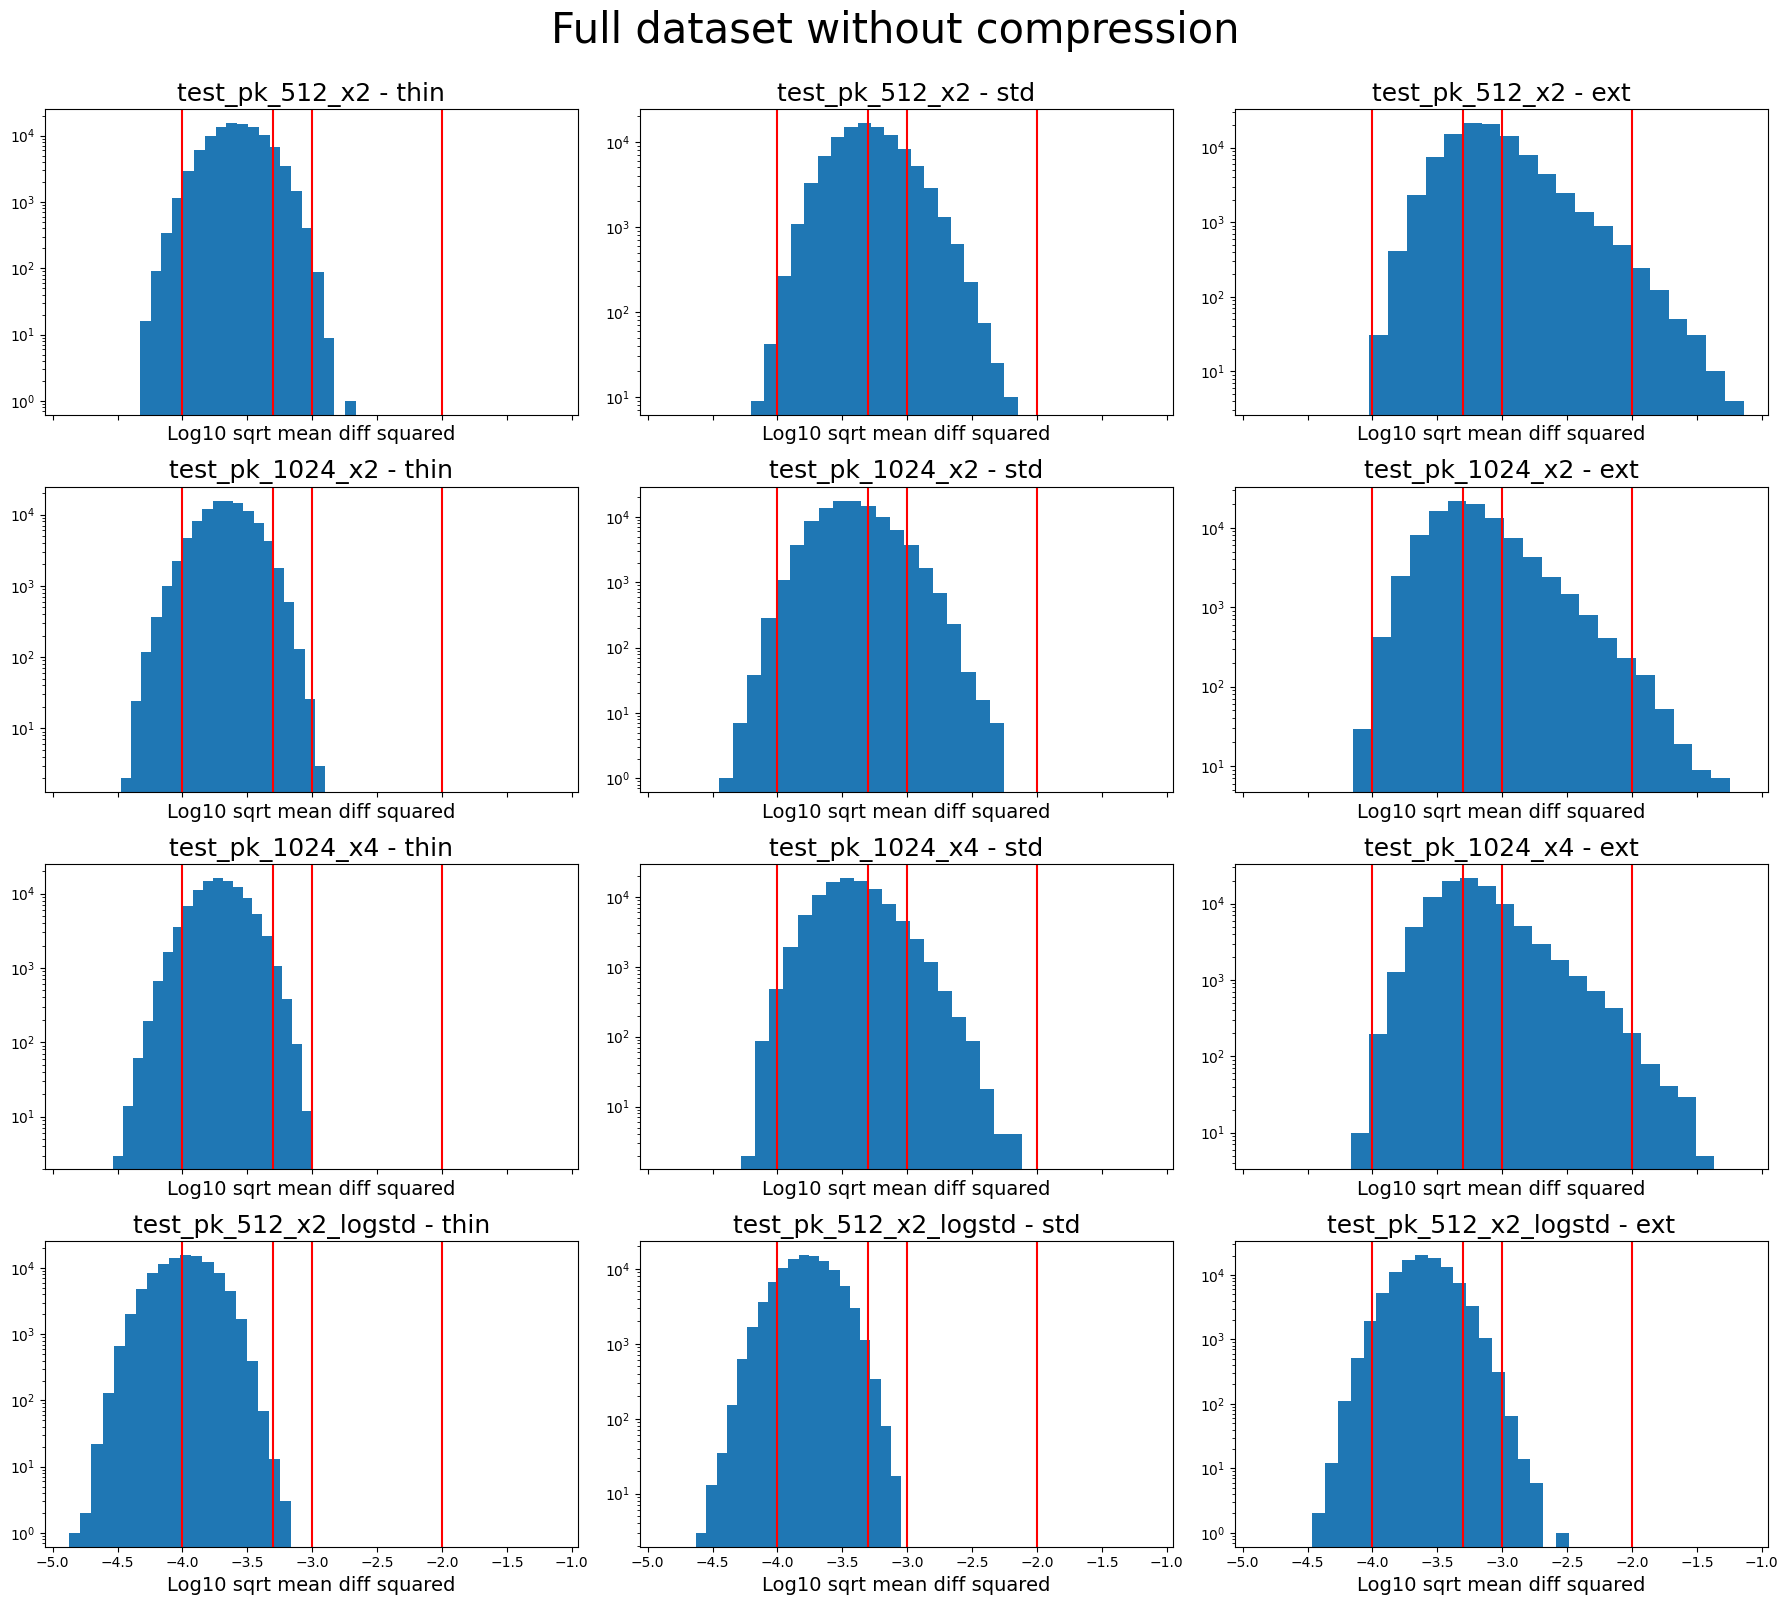

| name                  | >0.01%   | >0.05%   | >0.1%   | >1.0%   | Time emu (s)   | Time get_y_emu (s)   |
|-----------------------+----------+----------+---------+---------+----------------+----------------------|
| test_pk_512_x2        |          |          |         |         |                |                      |
| ---> thin             | 98.516%  | 9.434%   | 0.107%  | 0.000%  | 2.3e-06        | 1.1e-05              |
| ---> std              | 99.950%  | 48.926%  | 12.209% | 0.000%  | 2.2e-06        | 1.0e-05              |
| ---> ext              | 99.999%  | 74.172%  | 30.824% | 0.451%  | 2.2e-06        | 1.0e-05              |
| test_pk_1024_x2       |          |          |         |         |                |                      |
| ---> thin             | 96.121%  | 2.724%   | 0.008%  | 0.000%  | 3.4e-06        | 1.2e-05              |
| ---> std              | 99.601%  | 29.851%  | 5.374%  | 0.000%  | 3.4e-06        | 1.2e-05              |
| ---> ext              | 99

In [18]:
show_summary(emudata, x_data, y_data, paths_emu, dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.])

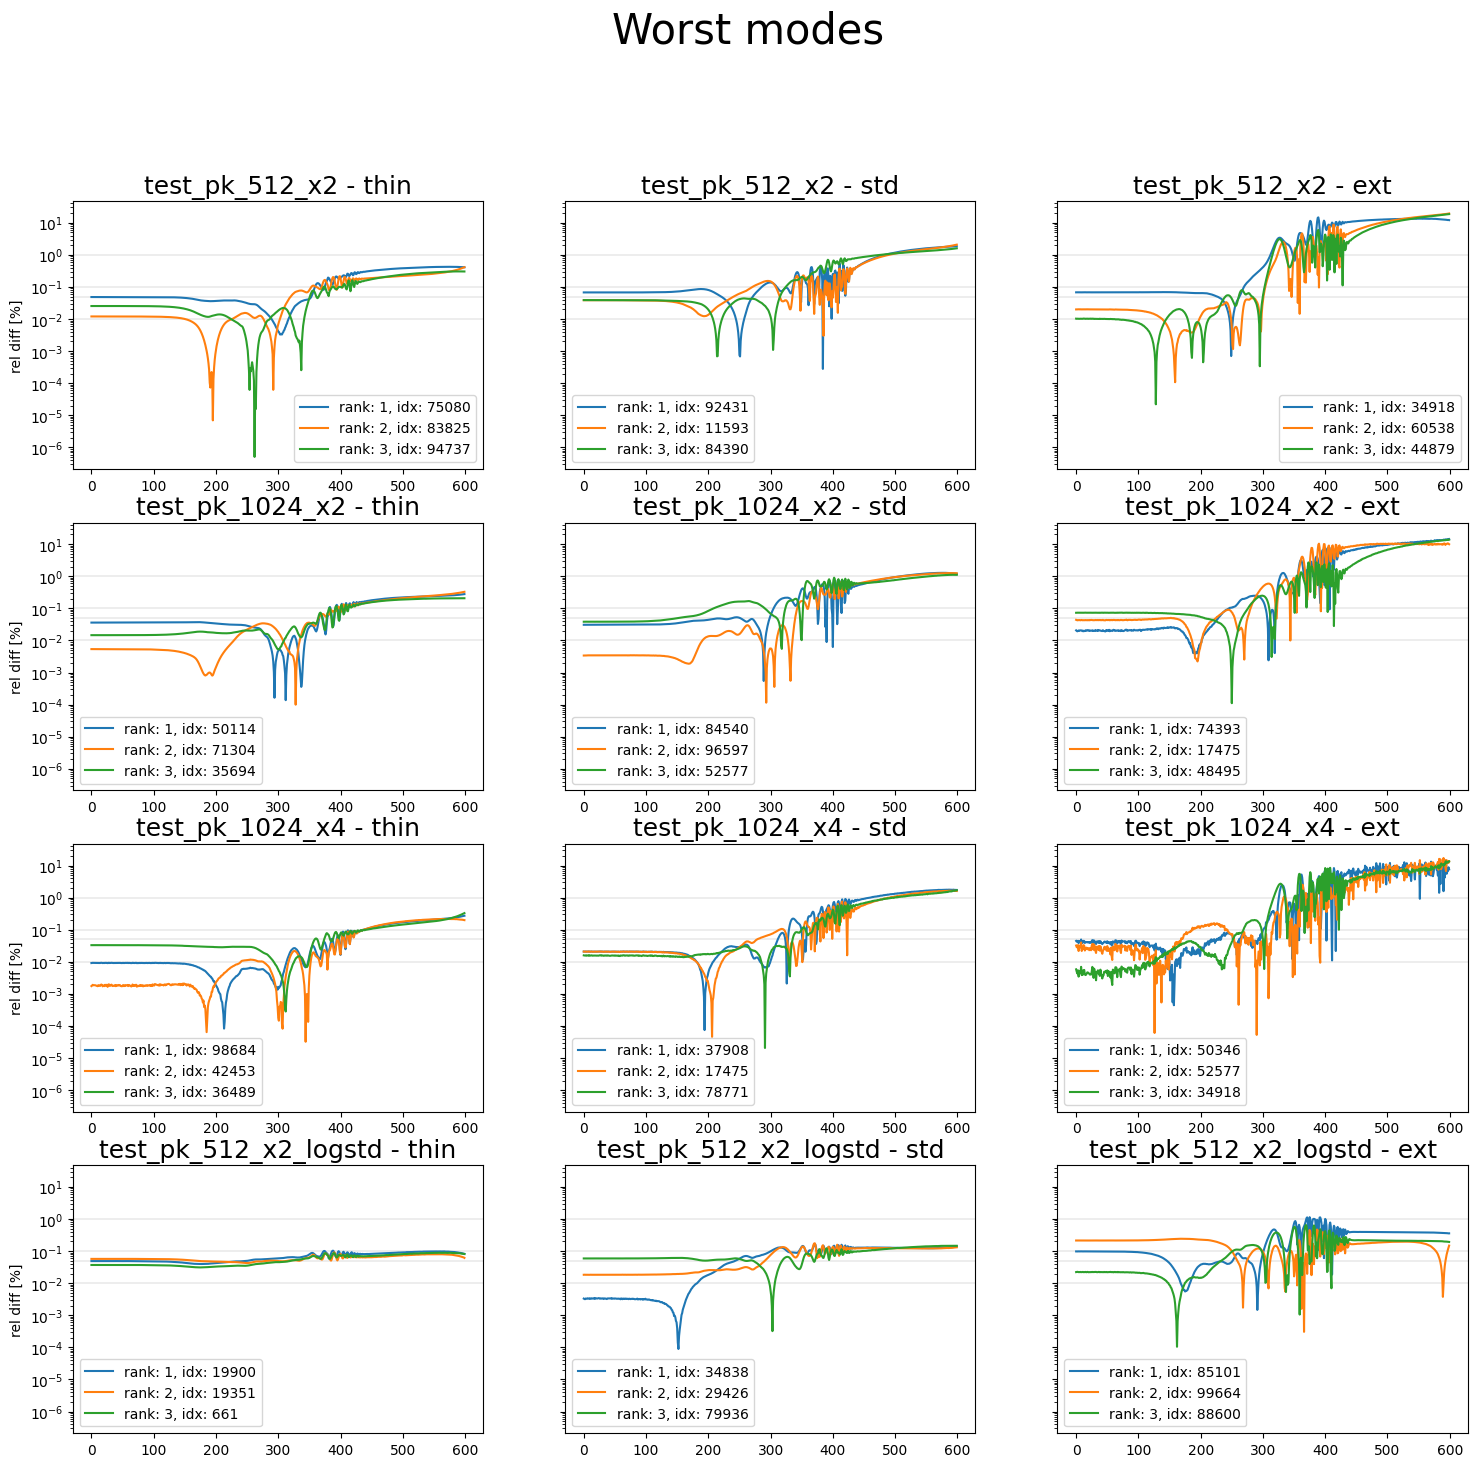

In [19]:
plot_worst_modes(emudata, paths_emu, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.])

## Pk matter

In [20]:
spectrum_type = 'pk'
spectrum = 'pk_m'
paths_emu = [
    'lcdm/train/test_pk_512_x2_logstd',
    # 'lcdm/train/test_pk_512_x4_logstd',
    # 'lcdm/train/test_pk_1024_x2_logstd',
    'lcdm/train/test_pk_1024_x4_logstd',
]

In [21]:
# Load emulators
emudata = load_emus(paths_emu, dataset_ranges, root)
# Load data
x_data, y_data = load_data(spectrum, spectrum_type, dataset_ranges, root)

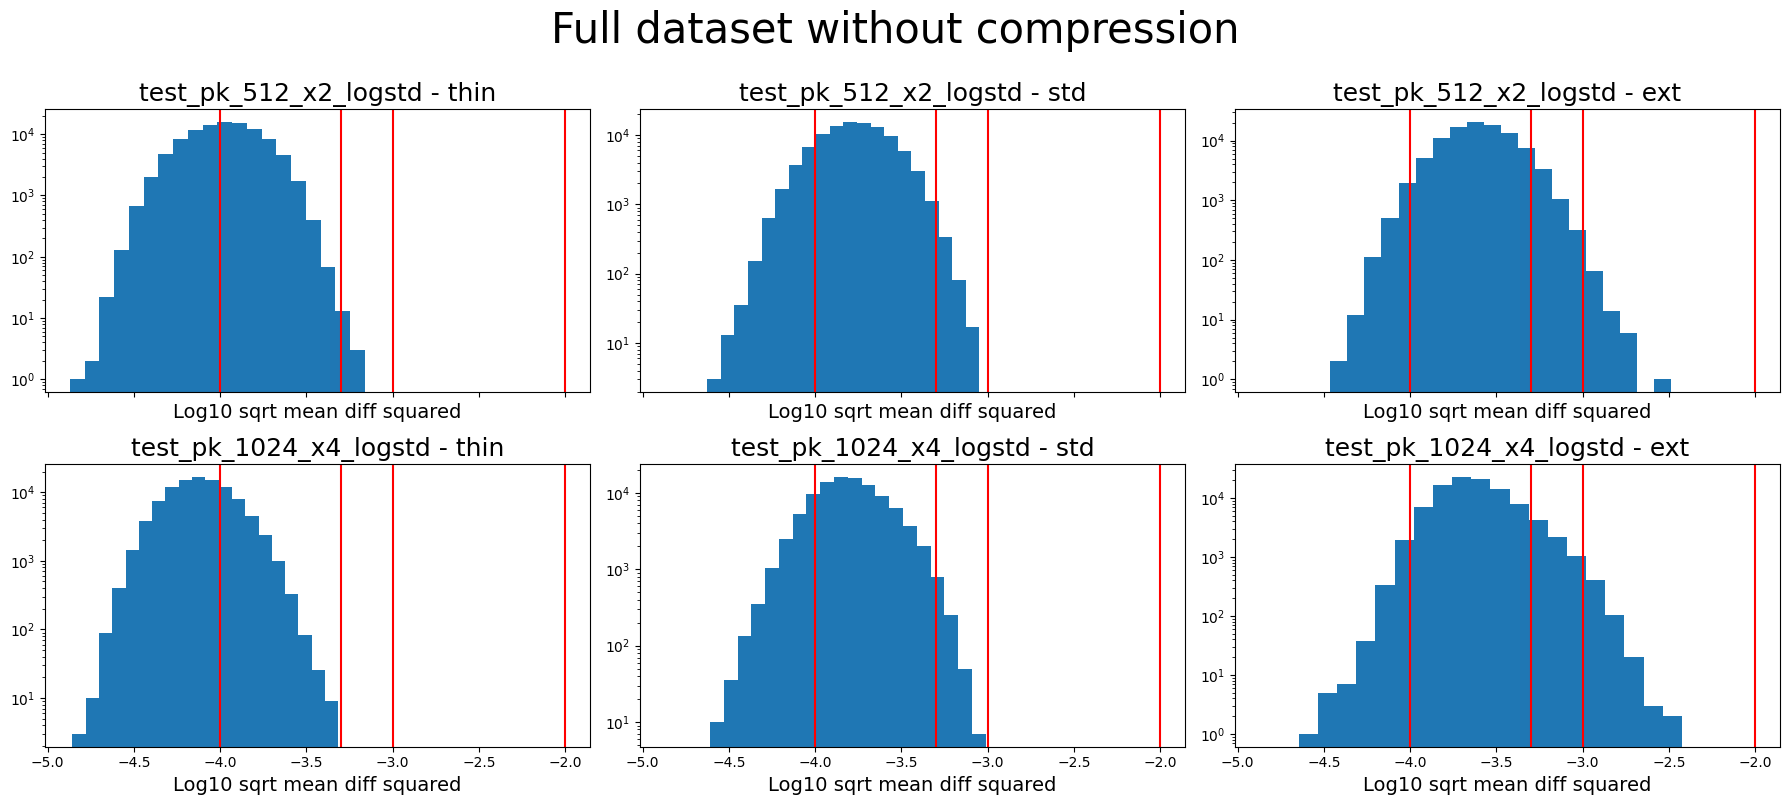

| name                   | >0.01%   | >0.05%   | >0.1%   | >1.0%   | Time emu (s)   | Time get_y_emu (s)   |
|------------------------+----------+----------+---------+---------+----------------+----------------------|
| test_pk_512_x2_logstd  |          |          |         |         |                |                      |
| ---> thin              | 55.238%  | 0.010%   | 0.000%  | 0.000%  | 2.1e-06        | 1.6e-05              |
| ---> std               | 87.591%  | 0.592%   | 0.000%  | 0.000%  | 2.5e-06        | 1.7e-05              |
| ---> ext               | 98.289%  | 6.120%   | 0.115%  | 0.000%  | 2.5e-06        | 1.8e-05              |
| test_pk_1024_x4_logstd |          |          |         |         |                |                      |
| ---> thin              | 26.423%  | 0.000%   | 0.000%  | 0.000%  | 6.6e-06        | 2.1e-05              |
| ---> std               | 85.037%  | 0.684%   | 0.000%  | 0.000%  | 6.1e-06        | 2.1e-05              |
| ---> ext         

In [22]:
show_summary(emudata, x_data, y_data, paths_emu, dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.])

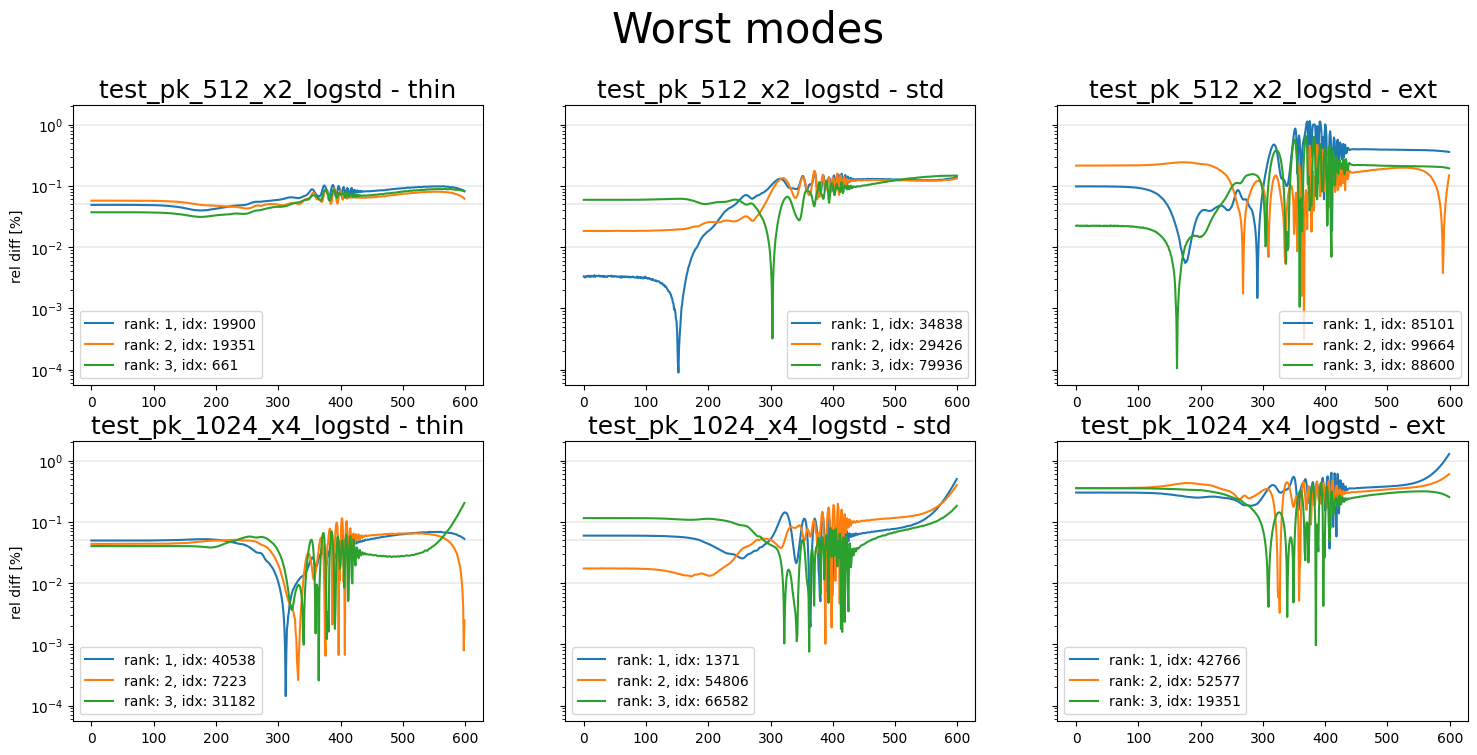

In [23]:
plot_worst_modes(emudata, paths_emu, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.])